In [2]:
import geopandas as gpd
gdf = gpd.read_file("../outputs/ward_heat_summary.geojson")
print(gdf["PREDICTED_LST_C"].isna().sum(), "wards with missing predictions")
print(gdf["pixel_count"].describe())

33 wards with missing predictions
count     108.000000
mean      961.842593
std      1152.336928
min       200.000000
25%       397.750000
50%       644.500000
75%      1083.250000
max      9861.000000
Name: pixel_count, dtype: float64


In [6]:
import geopandas as gpd

gdf = gpd.read_file("../outputs/ward_heat_summary.geojson")
gdf_m = gdf.to_crs(epsg=32645)  # UTM zone 45N — correct projected CRS for Kolkata

gdf_m["area_km2"] = gdf_m.geometry.area / 1e6

missing_mask = gdf["PREDICTED_LST_C"].isna()

print("Missing wards - area stats (km^2):")
print(gdf_m.loc[missing_mask, "area_km2"].describe())

print("\nAll wards - area stats (km^2):")
print(gdf_m["area_km2"].describe())

Missing wards - area stats (km^2):
count    33.000000
mean      2.248401
std       2.103449
min       0.667431
25%       1.161284
50%       1.676345
75%       2.546477
max      11.943159
Name: area_km2, dtype: float64

All wards - area stats (km^2):
count    141.000000
mean       1.323218
std        1.671044
min        0.164369
25%        0.438490
50%        0.887936
75%        1.614938
max       11.943159
Name: area_km2, dtype: float64


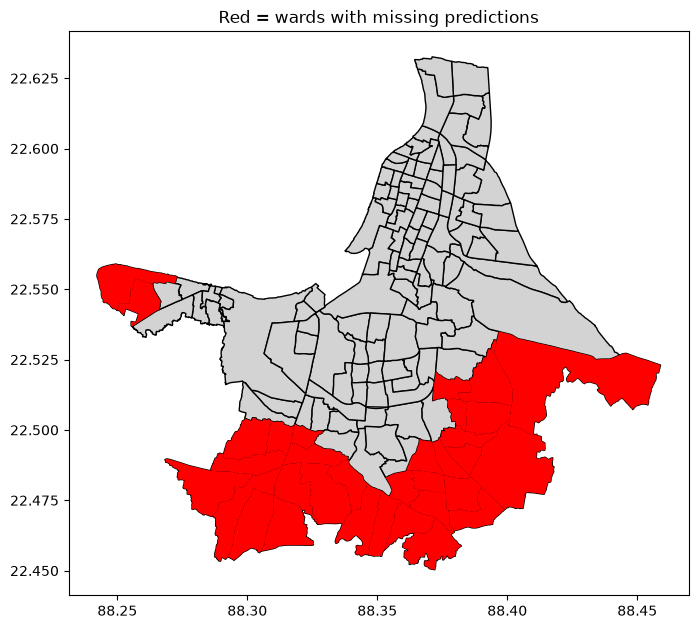

In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt
import ee

# your GAUL boundary (re-fetch same way gee_fetch.py does)
# if you have it saved/exportable, otherwise approximate via city.geometry().getInfo()

wards = gpd.read_file("../outputs/ward_heat_summary.geojson")
fig, ax = plt.subplots(figsize=(8, 8))
wards.plot(ax=ax, color="lightgrey", edgecolor="black")
wards[wards["PREDICTED_LST_C"].isna()].plot(ax=ax, color="red")
plt.title("Red = wards with missing predictions")
plt.savefig("../outputs/missing_wards_check.png", dpi=150)